#2.

In [1]:
import os, random, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from scipy.stats import ks_2samp
from PIL import Image, UnidentifiedImageError

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120})
print("Imports OK.")

Imports OK.


@3.

In [2]:
# ── EDIT THESE TWO PATHS ────────────────────────────────────────────────────
CSV_PATH        = "final_labelled.csv"          # path to your labelled CSV
IMG_ROOT        = "dataset"                     # parent of ellipticals/ spirals/ irregulars/
SPOT_CHECK_N    = 200                           # images per class to integrity-check
# ────────────────────────────────────────────────────────────────────────────

LABEL_MAP  = {0: "Elliptical", 1: "Spiral", 2: "Irregular"}
LABEL_DIRS = {0: "ellipticals", 1: "spirals", 2: "irregulars"}
COLORS     = {0: "#4C72B0", 1: "#55A868", 2: "#C44E52"}

REQUIRED_COLS = [
    "dr7objid", "ra", "dec", "spec_z", "gz2class", "morphology_label",
    "gz2_suffix", "PR90", "PR50", "expMag", "deVMag",
    "t01_smooth_or_features_a01_smooth_debiased",
    "t01_smooth_or_features_a02_features_or_disk_debiased",
    "t01_smooth_or_features_a03_star_or_artifact_debiased",
    "t08_odd_feature_a21_disturbed_debiased",
    "t08_odd_feature_a22_irregular_debiased",
    "t08_odd_feature_a24_merger_debiased",
    "gswlc_LOGMSTAR", "gswlc_LOGSFRSED", "gswlc_AFUV",
    "gswlc_AB", "gswlc_AV", "gswlc_Z",
    "gswlc_FLAG_SED", "gswlc_FLAG_WISE", "gswlc_FLAG_UNWISE", "gswlc_FLAG_MGS",
]

BOUNDS = {
    "ra":              (0.0,   360.0),
    "dec":             (-90.0,  90.0),
    "spec_z":          (0.001,  0.25),
    "expMag":          (10.0,   24.0),
    "deVMag":          (10.0,   24.0),
    "PR90":            (0.0,    1.0),
    "PR50":            (0.0,    1.0),
    "gswlc_LOGMSTAR":  (6.0,   13.0),
    "gswlc_LOGSFRSED": (-5.0,   3.0),
    "gswlc_AFUV":      (0.0,   10.0),
    "gswlc_AB":        (0.0,    5.0),
    "gswlc_AV":        (0.0,    5.0),
}

T01_DEBIAS_COLS = [
    "t01_smooth_or_features_a01_smooth_debiased",
    "t01_smooth_or_features_a02_features_or_disk_debiased",
    "t01_smooth_or_features_a03_star_or_artifact_debiased",
]
T08_IRREG_COLS = [
    "t08_odd_feature_a21_disturbed_debiased",
    "t08_odd_feature_a22_irregular_debiased",
    "t08_odd_feature_a24_merger_debiased",
]

ELLIPTICAL_PREFIXES = ("E", "Ser", "Sen", "Seb")
SPIRAL_PREFIXES     = ("Sa", "Sb", "Sc", "Sd", "SBa", "SBb", "SBc", "SBd")
IRREGULAR_SUFFIXES  = ("(m)", "(i)", "(d)", "(o)")
DROPPED_SUFFIXES    = ("(r)", "(l)", "(u)")

print("Config set.")

Config set.


#4.

In [3]:
_results = []

def log(section, status, msg):
    icons = {"PASS": "✅", "WARN": "⚠️ ", "FAIL": "❌", "INFO": "ℹ️ "}
    print(f"  {icons.get(status,'   ')} [{status}] {msg}")
    _results.append((section, status, msg))

def section_header(title):
    bar = "─" * 68
    print(f"\n{bar}\n  {title}\n{bar}")

def pct(n, total):
    return f"{n:,} ({100*n/total:.2f}%)" if total else str(n)

#5.

In [4]:
assert os.path.exists(CSV_PATH), f"File not found: {CSV_PATH}"
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Loaded  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df.head(3)

Loaded  31,374 rows  ×  269 columns


,specobjid_x,dr8objid,dr7objid,ra,dec,rastring,decstring,sample,gz2class,total_classifications,...,gswlc_AVERR,gswlc_FLAG_SED,gswlc_UV_SURVEY,gswlc_LOGSFRAW,gswlc_FLAG_WISE,gswlc_LOGSFRUW,gswlc_FLAG_UNWISE,gswlc_FLAG_MGS,gz2_suffix,morphology_label
0,3.253972e+17,1.237649e+18,587722981743394927,187.53172,-1.159705,30:07.6,-01:09:34.9,original,Sc?t,42,...,0.046,0,1,0.28,0,0.193,0,1,NaN,1
1,3.265269e+17,1.237649e+18,587722981744181303,189.39348,-1.245809,37:34.4,-01:14:44.9,original,Er,45,...,0.078,0,1,-99.00,5,-99.000,5,1,NaN,0
2,3.265231e+17,1.237649e+18,587722981744181387,189.44113,-1.238130,37:45.9,-01:14:17.3,original,Ei,43,...,0.082,0,1,-99.00,5,-99.000,5,1,NaN,0


#6.

In [5]:
section_header("SCHEMA INTEGRITY")

log("schema", "INFO", f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    log("schema", "FAIL", f"Missing required columns ({len(missing)}): {missing}")
else:
    log("schema", "PASS", "All required columns present")

unexpected = set(df["morphology_label"].unique()) - {0, 1, 2}
if unexpected:
    log("schema", "FAIL", f"morphology_label has unexpected values: {unexpected}")
else:
    log("schema", "PASS", "morphology_label values are exactly {0, 1, 2}")

log("schema", "INFO", f"dr7objid dtype = {df['dr7objid'].dtype}")
log("schema", "INFO", f"gz2class sample values: {df['gz2class'].dropna().unique()[:8].tolist()}")


────────────────────────────────────────────────────────────────────
  SCHEMA INTEGRITY
────────────────────────────────────────────────────────────────────
  ℹ️  [INFO] Shape: 31,374 rows x 269 columns
  ✅ [PASS] All required columns present
  ✅ [PASS] morphology_label values are exactly {0, 1, 2}
  ℹ️  [INFO] dr7objid dtype = int64
  ℹ️  [INFO] gz2class sample values: ['Sc?t', 'Er', 'Ei', 'Er(m)', 'Sc2t', 'Sc(m)', 'Sb(o)', 'Sc1t(i)']


#7.


────────────────────────────────────────────────────────────────────
  CLASS DISTRIBUTION & BALANCE
────────────────────────────────────────────────────────────────────
  ℹ️  [INFO]   Class 0 (Elliptical  ): 12,643 (40.30%)
  ℹ️  [INFO]   Class 1 (Spiral      ): 10,336 (32.94%)
  ℹ️  [INFO]   Class 2 (Irregular   ): 8,395 (26.76%)
  ✅ [PASS] Class balance acceptable (ratio = 1.5x)


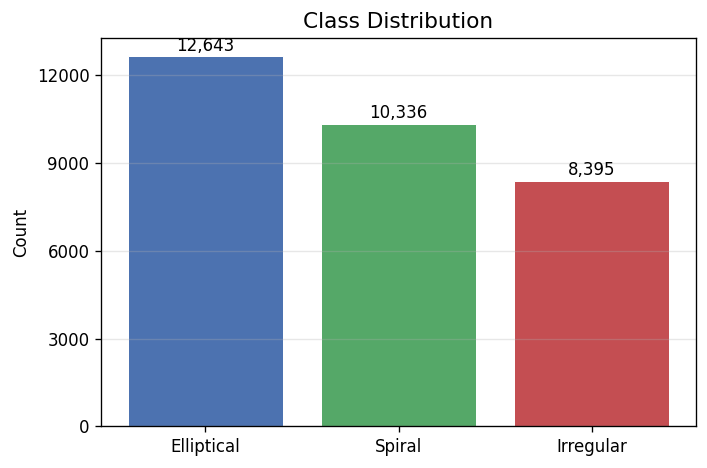

In [6]:
section_header("CLASS DISTRIBUTION & BALANCE")

counts = df["morphology_label"].value_counts().sort_index()
total  = len(df)
for lbl, cnt in counts.items():
    log("dist", "INFO", f"  Class {lbl} ({LABEL_MAP.get(lbl,'?'):12s}): {pct(cnt, total)}")

mx, mn = counts.max(), counts.min()
ratio  = mx / mn if mn > 0 else float("inf")
if ratio > 5:
    log("dist", "FAIL", f"Severe class imbalance — majority/minority = {ratio:.1f}x")
elif ratio > 2:
    log("dist", "WARN", f"Moderate class imbalance — ratio = {ratio:.1f}x  (consider class weighting / oversampling)")
else:
    log("dist", "PASS", f"Class balance acceptable (ratio = {ratio:.1f}x)")

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar([LABEL_MAP[i] for i in range(3)], counts.values,
              color=[COLORS[i] for i in range(3)], edgecolor="white", linewidth=0.6)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{val:,}", ha="center", fontsize=10)
ax.set_title("Class Distribution", fontsize=13)
ax.set_ylabel("Count")
ax.yaxis.set_major_locator(MaxNLocator(5))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#8.

In [7]:
section_header("IMAGE <-> LABEL CONSISTENCY")

img_root = Path(IMG_ROOT)
if not img_root.exists():
    log("images", "FAIL", f"Image root not found: {img_root.resolve()}")
else:
    folder_counts = {}
    for lbl, folder in LABEL_DIRS.items():
        p = img_root / folder
        if not p.exists():
            log("images", "FAIL", f"Subfolder missing: {p.resolve()}")
            folder_counts[lbl] = 0
        else:
            imgs = list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png"))
            folder_counts[lbl] = len(imgs)
            log("images", "INFO", f"  {folder:15s}: {len(imgs):,} files on disk")

    csv_counts = df["morphology_label"].value_counts().sort_index()
    for lbl in [0, 1, 2]:
        csv_n  = csv_counts.get(lbl, 0)
        disk_n = folder_counts.get(lbl, 0)
        diff   = abs(csv_n - disk_n)
        if diff == 0:
            log("images", "PASS", f"  Class {lbl}: CSV({csv_n:,}) = Disk({disk_n:,})")
        elif diff <= 5:
            log("images", "WARN", f"  Class {lbl}: CSV({csv_n:,}) vs Disk({disk_n:,}) — diff={diff} (matches ~3 removed entries)")
        else:
            log("images", "FAIL", f"  Class {lbl}: CSV({csv_n:,}) vs Disk({disk_n:,}) — diff={diff} — investigate!")


────────────────────────────────────────────────────────────────────
  IMAGE <-> LABEL CONSISTENCY
────────────────────────────────────────────────────────────────────
  ℹ️  [INFO]   ellipticals    : 12,643 files on disk
  ℹ️  [INFO]   spirals        : 10,336 files on disk
  ℹ️  [INFO]   irregulars     : 8,395 files on disk
  ✅ [PASS]   Class 0: CSV(12,643) = Disk(12,643)
  ✅ [PASS]   Class 1: CSV(10,336) = Disk(10,336)
  ✅ [PASS]   Class 2: CSV(8,395) = Disk(8,395)


#9.


────────────────────────────────────────────────────────────────────
  MISSING / NULL / INFINITE VALUES
────────────────────────────────────────────────────────────────────
  ⚠️  [WARN]   gz2_suffix                                   : 22,979 (73.24%) null
  ✅ [PASS] No +/-Inf values in numeric required columns


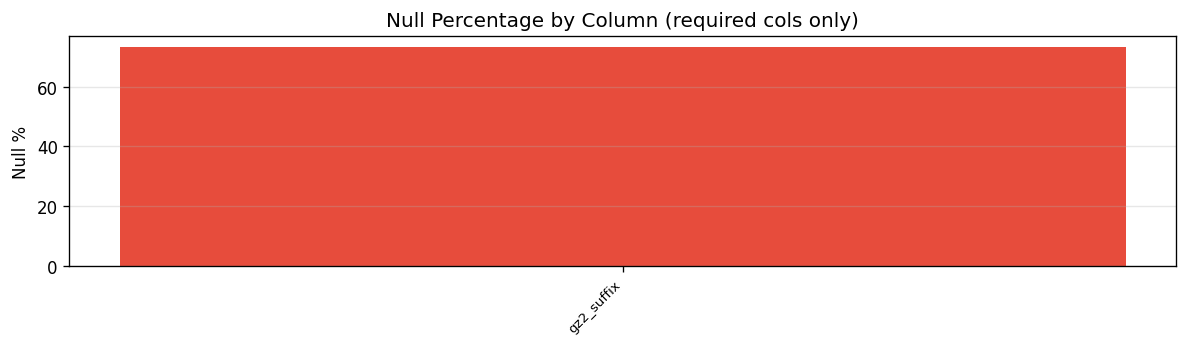

In [8]:
section_header("MISSING / NULL / INFINITE VALUES")

avail = [c for c in REQUIRED_COLS if c in df.columns]
null_series = df[avail].isnull().sum()
null_cols   = null_series[null_series > 0]

if null_cols.empty:
    log("nulls", "PASS", "No nulls in any required column")
else:
    critical = {"dr7objid", "morphology_label", "ra", "dec", "spec_z", "gz2class"}
    for col, n in null_cols.sort_values(ascending=False).items():
        log("nulls", "FAIL" if col in critical else "WARN",
            f"  {col:45s}: {pct(n, len(df))} null")

num_cols = df[avail].select_dtypes(include=np.number).columns
inf_counts = {c: int(np.isinf(df[c]).sum()) for c in num_cols if np.isinf(df[c]).sum() > 0}
if inf_counts:
    for col, n in inf_counts.items():
        log("nulls", "FAIL", f"  {col}: {n:,} +/-Inf values")
else:
    log("nulls", "PASS", "No +/-Inf values in numeric required columns")

gswlc_null = [c for c in null_cols.index if c.startswith("gswlc_")]
if gswlc_null:
    log("nulls", "INFO", "  GSWLC null breakdown per class:")
    for lbl in [0, 1, 2]:
        sub = df[df["morphology_label"] == lbl]
        n   = sub[gswlc_null].isnull().sum().sum()
        log("nulls", "INFO", f"    Class {lbl} ({LABEL_MAP[lbl]}): {n:,} nulls across affected GSWLC cols")

if not null_cols.empty:
    fig, ax = plt.subplots(figsize=(10, 3))
    null_pct = (df[avail].isnull().mean() * 100).sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]
    ax.bar(range(len(null_pct)), null_pct.values, color="#e74c3c")
    ax.set_xticks(range(len(null_pct)))
    ax.set_xticklabels(null_pct.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Null %")
    ax.set_title("Null Percentage by Column (required cols only)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("  No nulls to plot.")

#10.

In [9]:
section_header("DUPLICATE DETECTION")

dup_ids = df["dr7objid"].duplicated().sum()
if dup_ids:
    log("dupes", "FAIL", f"{dup_ids:,} duplicate dr7objid — same galaxy in multiple rows")
    dup_mask = df["dr7objid"].duplicated(keep=False)
    log("dupes", "INFO", f"  Duplicated rows by label: {df[dup_mask]['morphology_label'].value_counts().to_dict()}")
else:
    log("dupes", "PASS", "No duplicate dr7objid values")

id_label   = df.groupby("dr7objid")["morphology_label"].nunique()
collisions = int((id_label > 1).sum())
if collisions:
    log("dupes", "FAIL", f"{collisions:,} dr7objid values have conflicting morphology_label assignments")
else:
    log("dupes", "PASS", "No label collisions on dr7objid")

coord_dupes = df.duplicated(subset=["ra", "dec"]).sum()
if coord_dupes:
    log("dupes", "WARN",
        f"{coord_dupes:,} rows share identical (ra, dec) — "
        "check for cross-match artefacts before train/val split")
else:
    log("dupes", "PASS", "No exact (ra, dec) duplicates")


────────────────────────────────────────────────────────────────────
  DUPLICATE DETECTION
────────────────────────────────────────────────────────────────────
  ✅ [PASS] No duplicate dr7objid values
  ✅ [PASS] No label collisions on dr7objid
  ✅ [PASS] No exact (ra, dec) duplicates


#11.

In [10]:
section_header("PHYSICAL-RANGE VALIDATION")

range_summary = []
for col, (lo, hi) in BOUNDS.items():
    if col not in df.columns:
        log("bounds", "WARN", f"  {col}: absent — skipped")
        continue
    series  = df[col].dropna()
    n_bad   = int(((series < lo) | (series > hi)).sum())
    pct_bad = 100 * n_bad / len(series) if len(series) else 0
    range_summary.append({"column": col, "min": series.min(), "max": series.max(),
                           "expected_lo": lo, "expected_hi": hi,
                           "n_out_of_range": n_bad, "pct_out": round(pct_bad, 3)})
    if n_bad == 0:
        log("bounds", "PASS",
            f"  {col:30s}  observed=[{series.min():.4g}, {series.max():.4g}]  ✓ within [{lo}, {hi}]")
    else:
        log("bounds", "FAIL" if pct_bad > 1 else "WARN",
            f"  {col:30s}: {n_bad:,} out-of-range ({pct_bad:.2f}%)  "
            f"observed=[{series.min():.4g}, {series.max():.4g}]  expected=[{lo}, {hi}]")
    if col in ("gswlc_LOGMSTAR", "gswlc_LOGSFRSED", "spec_z"):
        log("bounds", "INFO",
            f"    median={series.median():.3f}  std={series.std():.3f}  "
            f"p5={series.quantile(0.05):.3f}  p95={series.quantile(0.95):.3f}")

pd.DataFrame(range_summary).style.background_gradient(subset=["pct_out"], cmap="Reds")


────────────────────────────────────────────────────────────────────
  PHYSICAL-RANGE VALIDATION
────────────────────────────────────────────────────────────────────
  ✅ [PASS]   ra                              observed=[0.2156, 360]  ✓ within [0.0, 360.0]
  ✅ [PASS]   dec                             observed=[-3.722, 69.29]  ✓ within [-90.0, 90.0]
  ✅ [PASS]   spec_z                          observed=[0.01006, 0.2496]  ✓ within [0.001, 0.25]
  ℹ️  [INFO]     median=0.077  std=0.043  p5=0.025  p95=0.167
  ✅ [PASS]   expMag                          observed=[11.91, 18.2]  ✓ within [10.0, 24.0]
  ✅ [PASS]   deVMag                          observed=[11.93, 17.71]  ✓ within [10.0, 24.0]
  ❌ [FAIL]   PR90                          : 31,374 out-of-range (100.00%)  observed=[3.006, 45.87]  expected=[0.0, 1.0]
  ❌ [FAIL]   PR50                          : 31,374 out-of-range (100.00%)  observed=[1.021, 25.59]  expected=[0.0, 1.0]
  ✅ [PASS]   gswlc_LOGMSTAR                  observed=[7.706, 12.

,column,min,max,expected_lo,expected_hi,n_out_of_range,pct_out
0,ra,0.215613,359.984920,0.000000,360.000000,0,0.000000
1,dec,-3.722169,69.294395,-90.000000,90.000000,0,0.000000
2,spec_z,0.010055,0.249597,0.001000,0.250000,0,0.000000
3,expMag,11.906370,18.196860,10.000000,24.000000,0,0.000000
4,deVMag,11.928870,17.712390,10.000000,24.000000,0,0.000000
5,PR90,3.005530,45.869250,0.000000,1.000000,31374,100.000000
6,PR50,1.021491,25.588440,0.000000,1.000000,31374,100.000000
7,gswlc_LOGMSTAR,7.706000,12.300000,6.000000,13.000000,0,0.000000
8,gswlc_LOGSFRSED,-3.452000,2.453000,-5.000000,3.000000,0,0.000000
9,gswlc_AFUV,0.708000,5.658000,0.000000,10.000000,0,0.000000


#12.


────────────────────────────────────────────────────────────────────
  CROSS-MATCH INTERNAL CONSISTENCY
────────────────────────────────────────────────────────────────────
  ✅ [PASS]   RA: 0 rows differ > 2 arcsec (0.000%)  [median |Δ| = 0.0720 arcsec]
  ✅ [PASS]   Dec: 0 rows differ > 2 arcsec (0.000%)  [median |Δ| = 0.0036 arcsec]
  ✅ [PASS]   |Δz| > 0.002 (your tolerance): 0 rows  [median |Δz| = 0.00004]
  ✅ [PASS]   |Δz| > 0.010 (5× tolerance):  0 rows


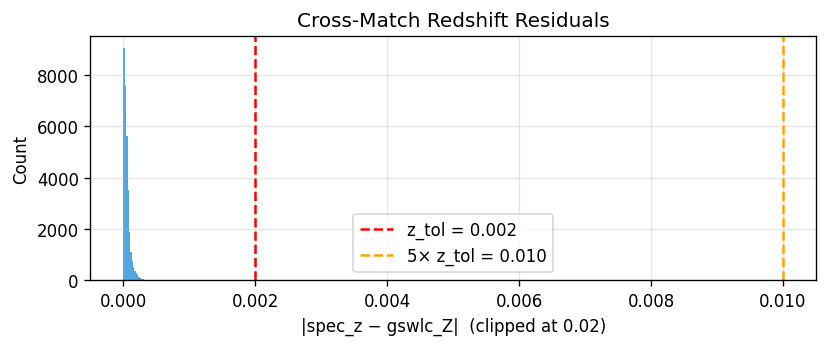

In [11]:
section_header("CROSS-MATCH INTERNAL CONSISTENCY")

for coord, col_a, col_b in [("RA", "ra", "ra_y"), ("Dec", "dec", "dec_y")]:
    if col_a not in df.columns or col_b not in df.columns:
        log("xmatch", "WARN", f"  {col_a} or {col_b} absent — skipped")
        continue
    tol   = 2 / 3600
    diff  = (df[col_a] - df[col_b]).abs()
    n_bad = int((diff > tol).sum())
    pct_v = 100 * n_bad / len(df)
    log("xmatch", "PASS" if n_bad == 0 else ("WARN" if pct_v < 0.5 else "FAIL"),
        f"  {coord}: {n_bad:,} rows differ > 2 arcsec ({pct_v:.3f}%)  "
        f"[median |Δ| = {diff.median()*3600:.4f} arcsec]")

if "spec_z" in df.columns and "gswlc_Z" in df.columns:
    dz   = (df["spec_z"] - df["gswlc_Z"]).abs()
    n_02 = int((dz > 0.002).sum())
    n_01 = int((dz > 0.010).sum())
    log("xmatch", "PASS" if n_02 == 0 else "WARN",
        f"  |Δz| > 0.002 (your tolerance): {n_02:,} rows  [median |Δz| = {dz.median():.5f}]")
    log("xmatch", "PASS" if n_01 == 0 else "WARN",
        f"  |Δz| > 0.010 (5× tolerance):  {n_01:,} rows")

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(dz.clip(upper=0.02), bins=80, color="#3498db", edgecolor="none", alpha=0.85)
    ax.axvline(0.002, color="red",    ls="--", lw=1.5, label="z_tol = 0.002")
    ax.axvline(0.010, color="orange", ls="--", lw=1.5, label="5× z_tol = 0.010")
    ax.set_xlabel("|spec_z − gswlc_Z|  (clipped at 0.02)")
    ax.set_ylabel("Count")
    ax.set_title("Cross-Match Redshift Residuals")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

#13.


────────────────────────────────────────────────────────────────────
  GZ2 VOTE-FRACTION SANITY
────────────────────────────────────────────────────────────────────
  ⚠️  [WARN]   T01 debiased sum ≈ 1.0:  14,248 rows deviate > 0.05  [mean=1.0130, std=0.0878]


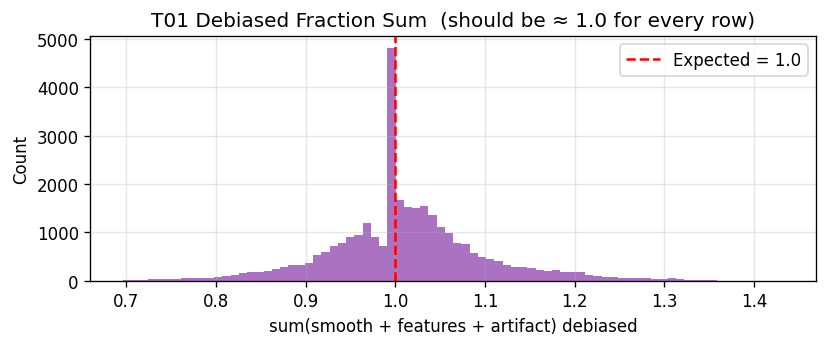

  ✅ [PASS]   All 37 debiased columns are in [0, 1]
  ✅ [PASS]   _flag cell rate across 37 columns: 6.46%  (total flagged cells: 74,941)
  ℹ️  [INFO]   T08 (disturbed / irregular / merger) debiased max by class:
  ℹ️  [INFO]     Class 0 (Elliptical  ): median=0.000  p75=0.167  frac≥0.5=13.9%
  ℹ️  [INFO]     Class 1 (Spiral      ): median=0.333  p75=0.556  frac≥0.5=34.3%
  ℹ️  [INFO]     Class 2 (Irregular   ): median=0.498  p75=0.622  frac≥0.5=49.7%


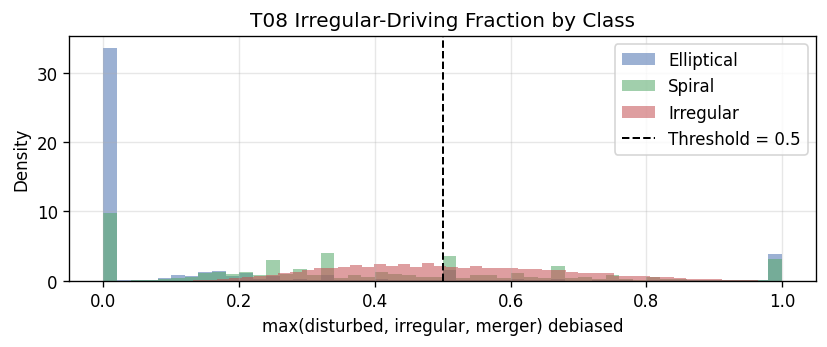

In [12]:
section_header("GZ2 VOTE-FRACTION SANITY")

avail_t01 = [c for c in T01_DEBIAS_COLS if c in df.columns]
if len(avail_t01) == 3:
    t01_sum   = df[avail_t01].sum(axis=1)
    n_bad_sum = int(((t01_sum - 1.0).abs() > 0.05).sum())
    log("votes", "PASS" if n_bad_sum == 0 else "WARN",
        f"  T01 debiased sum ≈ 1.0:  {n_bad_sum:,} rows deviate > 0.05  "
        f"[mean={t01_sum.mean():.4f}, std={t01_sum.std():.4f}]")

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(t01_sum, bins=80, color="#9b59b6", edgecolor="none", alpha=0.85)
    ax.axvline(1.0, color="red", ls="--", lw=1.5, label="Expected = 1.0")
    ax.set_xlabel("sum(smooth + features + artifact) debiased")
    ax.set_ylabel("Count")
    ax.set_title("T01 Debiased Fraction Sum  (should be ≈ 1.0 for every row)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    log("votes", "WARN", "T01 debiased columns partially absent — sum check skipped")

debias_cols  = [c for c in df.columns if c.endswith("_debiased")]
out_of_range = sum(int(((df[c] < 0) | (df[c] > 1)).sum()) for c in debias_cols)
if out_of_range:
    log("votes", "WARN", f"  {out_of_range:,} cells have debiased fraction outside [0, 1]")
else:
    log("votes", "PASS", f"  All {len(debias_cols)} debiased columns are in [0, 1]")

flag_cols     = [c for c in df.columns if c.endswith("_flag")]
total_flagged = sum(int(df[c].sum()) for c in flag_cols if c in df.columns)
flag_rate     = total_flagged / (len(flag_cols) * len(df) + 1)
log("votes", "PASS" if flag_rate < 0.10 else "WARN",
    f"  _flag cell rate across {len(flag_cols)} columns: {100*flag_rate:.2f}%  "
    f"(total flagged cells: {total_flagged:,})")

avail_t08 = [c for c in T08_IRREG_COLS if c in df.columns]
if avail_t08:
    log("votes", "INFO", "  T08 (disturbed / irregular / merger) debiased max by class:")
    for lbl in [0, 1, 2]:
        sub = df[df["morphology_label"] == lbl][avail_t08].max(axis=1)
        log("votes", "INFO",
            f"    Class {lbl} ({LABEL_MAP[lbl]:12s}): "
            f"median={sub.median():.3f}  p75={sub.quantile(0.75):.3f}  "
            f"frac≥0.5={100*(sub>=0.5).mean():.1f}%")

    fig, ax = plt.subplots(figsize=(7, 3))
    for lbl in [0, 1, 2]:
        sub = df[df["morphology_label"] == lbl][avail_t08].max(axis=1).dropna()
        ax.hist(sub, bins=50, alpha=0.55, color=COLORS[lbl],
                label=LABEL_MAP[lbl], density=True, histtype="stepfilled")
    ax.axvline(0.5, color="black", ls="--", lw=1.2, label="Threshold = 0.5")
    ax.set_xlabel("max(disturbed, irregular, merger) debiased")
    ax.set_ylabel("Density")
    ax.set_title("T08 Irregular-Driving Fraction by Class")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

#14.


────────────────────────────────────────────────────────────────────
  gz2class <-> morphology_label INTERNAL CONSISTENCY
────────────────────────────────────────────────────────────────────
  ✅ [PASS]   All Ellipticals have expected gz2class prefix (E / Ser / Sen / Seb)
  ✅ [PASS]   All Spirals have expected gz2class prefix (Sa/Sb/Sc/Sd/SBa/SBb/SBc/SBd)
  ⚠️  [WARN]   Irregulars explained by suffix or T08≥0.5: 4,174/8,395 (49.72%)
  ⚠️  [WARN]   4,221 Irregulars have neither a known suffix nor T08≥0.5 — review classification rules
  ✅ [PASS]   No dropped-suffix galaxies (ring / lens / dust-lane) remain
  ✅ [PASS]   No artifact-class galaxies in dataset


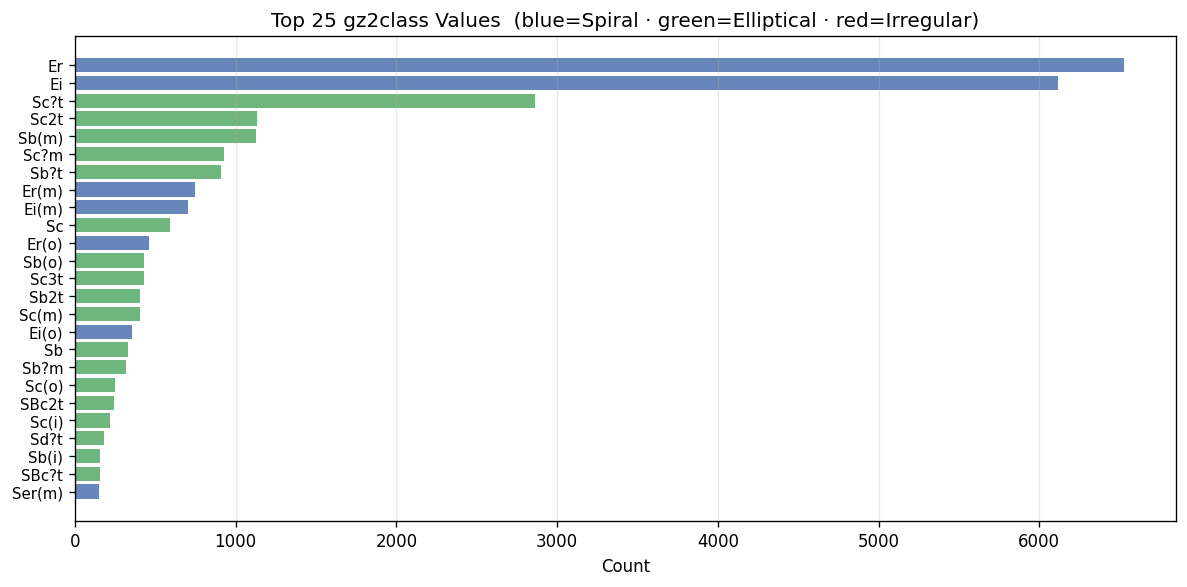

In [13]:
section_header("gz2class <-> morphology_label INTERNAL CONSISTENCY")

ell = df[df["morphology_label"] == 0]
bad = ell[~ell["gz2class"].str.startswith(ELLIPTICAL_PREFIXES, na=False)]
if len(bad):
    log("labels", "WARN",
        f"  {len(bad):,} Ellipticals ({100*len(bad)/max(len(ell),1):.2f}%) have non-elliptical gz2class prefix")
    log("labels", "INFO", f"    Top offending gz2class: {bad['gz2class'].value_counts().head(5).to_dict()}")
else:
    log("labels", "PASS", "  All Ellipticals have expected gz2class prefix (E / Ser / Sen / Seb)")

spi = df[df["morphology_label"] == 1]
bad = spi[~spi["gz2class"].str.startswith(SPIRAL_PREFIXES, na=False)]
if len(bad):
    log("labels", "WARN",
        f"  {len(bad):,} Spirals ({100*len(bad)/max(len(spi),1):.2f}%) have non-spiral gz2class prefix")
    log("labels", "INFO", f"    Top offending gz2class: {bad['gz2class'].value_counts().head(5).to_dict()}")
else:
    log("labels", "PASS", "  All Spirals have expected gz2class prefix (Sa/Sb/Sc/Sd/SBa/SBb/SBc/SBd)")

if "gz2_suffix" in df.columns:
    irreg         = df[df["morphology_label"] == 2]
    suffix_driven = irreg["gz2_suffix"].isin(list(IRREGULAR_SUFFIXES))
    avail_t08     = [c for c in T08_IRREG_COLS if c in df.columns]
    t08_driven    = irreg[avail_t08].max(axis=1) >= 0.5 if avail_t08 else pd.Series(False, index=irreg.index)
    fully_explained = (suffix_driven | t08_driven).sum()
    unexplained     = len(irreg) - fully_explained
    log("labels", "INFO" if unexplained == 0 else "WARN",
        f"  Irregulars explained by suffix or T08≥0.5: "
        f"{fully_explained:,}/{len(irreg):,} ({100*fully_explained/max(len(irreg),1):.2f}%)")
    if unexplained:
        log("labels", "WARN",
            f"  {unexplained:,} Irregulars have neither a known suffix nor T08≥0.5 — review classification rules")

if "gz2_suffix" in df.columns:
    dropped = df[df["gz2_suffix"].isin(list(DROPPED_SUFFIXES))]
    if len(dropped):
        log("labels", "FAIL",
            f"  {len(dropped):,} rows have DROPPED suffix (r/l/u) still present!")
        log("labels", "INFO", f"    Breakdown: {dropped['gz2_suffix'].value_counts().to_dict()}")
    else:
        log("labels", "PASS", "  No dropped-suffix galaxies (ring / lens / dust-lane) remain")

artifacts = df[df["gz2class"].str.startswith("A", na=False)]
if len(artifacts):
    log("labels", "FAIL",
        f"  {len(artifacts):,} artifact-class (gz2class='A...') rows remain — must remove")
else:
    log("labels", "PASS", "  No artifact-class galaxies in dataset")

top25 = df["gz2class"].value_counts().head(25)
bar_colors = []
for cls in top25.index:
    if str(cls).startswith(SPIRAL_PREFIXES):       bar_colors.append(COLORS[1])
    elif str(cls).startswith(ELLIPTICAL_PREFIXES): bar_colors.append(COLORS[0])
    else:                                          bar_colors.append(COLORS[2])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(top25)), top25.values, color=bar_colors, alpha=0.85, edgecolor="none")
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_title("Top 25 gz2class Values  (blue=Spiral · green=Elliptical · red=Irregular)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

#15.


────────────────────────────────────────────────────────────────────
  GSWLC QUALITY FLAGS
────────────────────────────────────────────────────────────────────
  ℹ️  [INFO]   gswlc_FLAG_SED  (SED fit quality  (0=good, 1=uncertain, 2=bad)):
  ℹ️  [INFO]       value=0: 31,374 (100.00%)
  ℹ️  [INFO]   gswlc_FLAG_WISE  (WISE photometry used (1=yes)):
  ℹ️  [INFO]       value=0: 11,488 (36.62%)
  ℹ️  [INFO]       value=5: 19,886 (63.38%)
  ℹ️  [INFO]   gswlc_FLAG_UNWISE  (unWISE photometry used (1=yes)):
  ℹ️  [INFO]       value=0: 12,910 (41.15%)
  ℹ️  [INFO]       value=5: 18,464 (58.85%)
  ℹ️  [INFO]   gswlc_FLAG_MGS  (SDSS Main Galaxy Sample member (1=yes)):
  ℹ️  [INFO]       value=0: 66 (0.21%)
  ℹ️  [INFO]       value=1: 31,308 (99.79%)
  ✅ [PASS]   FLAG_SED==2 (bad SED fit): 0 rows (0.00%) — consider excluding from training
  ✅ [PASS]   REDCHISQ > 10: 0 rows  [median=0.88, p95=4.38]


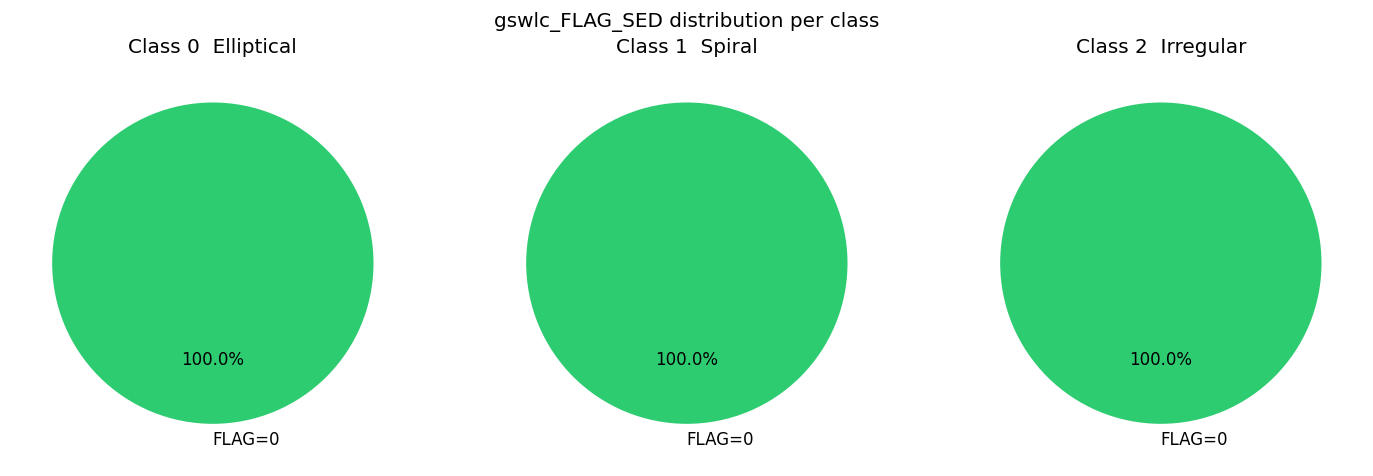

In [14]:
section_header("GSWLC QUALITY FLAGS")

flag_descs = {
    "gswlc_FLAG_SED":    "SED fit quality  (0=good, 1=uncertain, 2=bad)",
    "gswlc_FLAG_WISE":   "WISE photometry used (1=yes)",
    "gswlc_FLAG_UNWISE": "unWISE photometry used (1=yes)",
    "gswlc_FLAG_MGS":    "SDSS Main Galaxy Sample member (1=yes)",
}
for col, desc in flag_descs.items():
    if col not in df.columns:
        log("flags", "WARN", f"  {col}: absent"); continue
    vc = df[col].value_counts().sort_index()
    log("flags", "INFO", f"  {col}  ({desc}):")
    for val, cnt in vc.items():
        log("flags", "INFO", f"      value={val}: {pct(cnt, len(df))}")

if "gswlc_FLAG_SED" in df.columns:
    bad_sed = int((df["gswlc_FLAG_SED"] == 2).sum())
    pct_bad = 100 * bad_sed / len(df)
    log("flags", "PASS" if pct_bad < 1 else ("WARN" if pct_bad < 5 else "FAIL"),
        f"  FLAG_SED==2 (bad SED fit): {bad_sed:,} rows ({pct_bad:.2f}%) — consider excluding from training")

if "gswlc_REDCHISQ" in df.columns:
    rchi  = df["gswlc_REDCHISQ"].dropna()
    n_bad = int((rchi > 10).sum())
    log("flags", "PASS" if n_bad == 0 else "WARN",
        f"  REDCHISQ > 10: {n_bad:,} rows  [median={rchi.median():.2f}, p95={rchi.quantile(0.95):.2f}]")

if "gswlc_FLAG_SED" in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, lbl in zip(axes, [0, 1, 2]):
        sub = df[df["morphology_label"] == lbl]["gswlc_FLAG_SED"].value_counts().sort_index()
        ax.pie(sub.values, labels=[f"FLAG={v}" for v in sub.index],
               autopct="%1.1f%%", startangle=90,
               colors=["#2ecc71","#f39c12","#e74c3c"][:len(sub)])
        ax.set_title(f"Class {lbl}  {LABEL_MAP[lbl]}")
    fig.suptitle("gswlc_FLAG_SED distribution per class", fontsize=12)
    plt.tight_layout(); plt.show()

#16.

In [15]:
section_header("PER-CLASS PHYSICAL FEATURE STATISTICS")

phys_cols = ["spec_z", "gswlc_LOGMSTAR", "gswlc_LOGSFRSED",
             "gswlc_AFUV", "gswlc_AB", "gswlc_AV", "expMag"]
avail = [c for c in phys_cols if c in df.columns]

stats_rows = []
for col in avail:
    print(f"\n  ── {col}")
    for lbl in [0, 1, 2]:
        sub = df[df["morphology_label"] == lbl][col].dropna()
        if not len(sub): continue
        log("stats", "INFO",
            f"    Class {lbl} ({LABEL_MAP[lbl]:12s}): n={len(sub):,}  "
            f"median={sub.median():.3f}  mean={sub.mean():.3f}  std={sub.std():.3f}  "
            f"[p5={sub.quantile(0.05):.3f}, p95={sub.quantile(0.95):.3f}]")
        stats_rows.append({"feature": col, "class": LABEL_MAP[lbl],
                           "median": round(sub.median(), 3), "mean": round(sub.mean(), 3),
                           "std": round(sub.std(), 3)})
    for a, b in [(0,1),(0,2),(1,2)]:
        s_a = df[df["morphology_label"]==a][col].dropna()
        s_b = df[df["morphology_label"]==b][col].dropna()
        if len(s_a)>10 and len(s_b)>10:
            stat, pval = ks_2samp(s_a, s_b)
            log("stats","INFO", f"    KS({LABEL_MAP[a]} vs {LABEL_MAP[b]}): stat={stat:.3f}  p={pval:.2e}")

pd.DataFrame(stats_rows).pivot_table(index="feature", columns="class", values="median")


────────────────────────────────────────────────────────────────────
  PER-CLASS PHYSICAL FEATURE STATISTICS
────────────────────────────────────────────────────────────────────

  ── spec_z
  ℹ️  [INFO]     Class 0 (Elliptical  ): n=12,643  median=0.084  mean=0.093  std=0.050  [p5=0.025, p95=0.183]
  ℹ️  [INFO]     Class 1 (Spiral      ): n=10,336  median=0.069  mean=0.071  std=0.032  [p5=0.024, p95=0.130]
  ℹ️  [INFO]     Class 2 (Irregular   ): n=8,395  median=0.081  mean=0.086  std=0.039  [p5=0.028, p95=0.155]
  ℹ️  [INFO]     KS(Elliptical vs Spiral): stat=0.220  p=4.32e-242
  ℹ️  [INFO]     KS(Elliptical vs Irregular): stat=0.112  p=1.95e-55
  ℹ️  [INFO]     KS(Spiral vs Irregular): stat=0.149  p=7.75e-91

  ── gswlc_LOGMSTAR
  ℹ️  [INFO]     Class 0 (Elliptical  ): n=12,643  median=10.999  mean=10.886  std=0.596  [p5=9.734, p95=11.620]
  ℹ️  [INFO]     Class 1 (Spiral      ): n=10,336  median=10.547  mean=10.482  std=0.506  [p5=9.515, p95=11.208]
  ℹ️  [INFO]     Class 2 (Irreg

class,Elliptical,Irregular,Spiral
feature,,,
expMag,16.693,16.795,16.612
gswlc_AB,0.306,0.330,0.256
gswlc_AFUV,1.874,1.936,1.349
gswlc_AV,0.206,0.221,0.174
gswlc_LOGMSTAR,10.999,10.803,10.547
gswlc_LOGSFRSED,-0.891,-0.253,0.242
spec_z,0.084,0.081,0.069


#17.

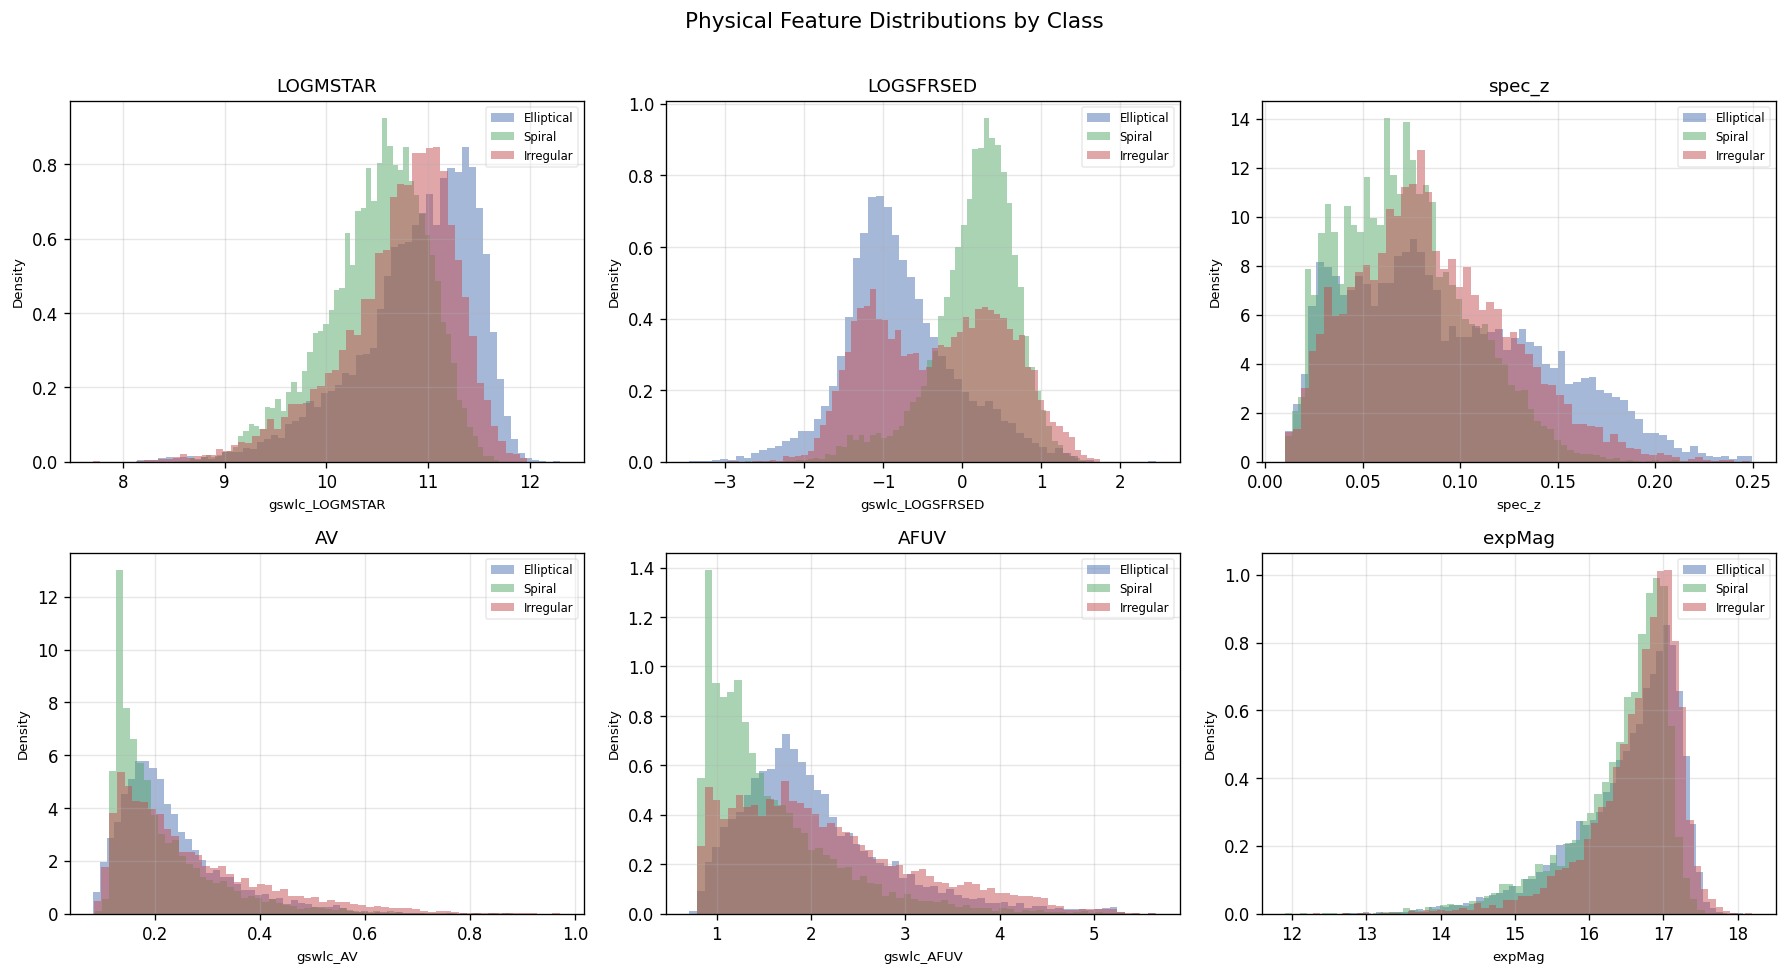

In [16]:
phys_plot = ["gswlc_LOGMSTAR", "gswlc_LOGSFRSED", "spec_z",
             "gswlc_AV", "gswlc_AFUV", "expMag"]
avail_plot = [c for c in phys_plot if c in df.columns]
n_cols     = 3
n_rows     = (len(avail_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, avail_plot):
    for lbl in [0, 1, 2]:
        sub = df[df["morphology_label"] == lbl][col].dropna()
        ax.hist(sub, bins=60, alpha=0.50, color=COLORS[lbl],
                label=LABEL_MAP[lbl], density=True, histtype="stepfilled")
    ax.set_title(col.replace("gswlc_", ""), fontsize=11)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7, framealpha=0.4)
    ax.grid(alpha=0.3)

for ax in axes[len(avail_plot):]:
    ax.set_visible(False)

plt.suptitle("Physical Feature Distributions by Class", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

#18.


────────────────────────────────────────────────────────────────────
  IMAGE-FILE INTEGRITY SPOT-CHECK
────────────────────────────────────────────────────────────────────
  ✅ [PASS]   ellipticals    : checked 200/12643 — corrupt=0, tiny=0, unexpected_mode=0
  ✅ [PASS]   spirals        : checked 200/10336 — corrupt=0, tiny=0, unexpected_mode=0
  ✅ [PASS]   irregulars     : checked 200/8395 — corrupt=0, tiny=0, unexpected_mode=0


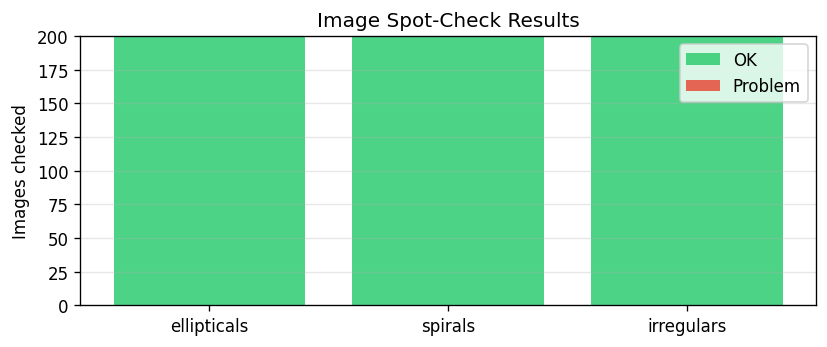

In [17]:
section_header("IMAGE-FILE INTEGRITY SPOT-CHECK")

img_root = Path(IMG_ROOT)
results  = {}

if not img_root.exists():
    log("imgcheck", "WARN", f"Image root not found: {img_root}")
else:
    for lbl, folder in LABEL_DIRS.items():
        p = img_root / folder
        if not p.exists():
            log("imgcheck", "WARN", f"  {folder}: folder missing"); continue

        imgs   = list(p.glob("*.jpg")) + list(p.glob("*.jpeg")) + list(p.glob("*.png"))
        sample = random.sample(imgs, min(SPOT_CHECK_N, len(imgs)))
        corrupt, wrong_mode, tiny = [], [], []

        for fp in sample:
            try:
                img = Image.open(fp); img.verify()
                img = Image.open(fp); img.load()
                w, h = img.size
                if w < 32 or h < 32:         tiny.append(fp.name)
                if img.mode not in ("RGB","L","RGBA"): wrong_mode.append((fp.name, img.mode))
            except Exception:
                corrupt.append(fp.name)

        results[folder] = {"checked": len(sample), "total": len(imgs),
                           "corrupt": len(corrupt), "tiny": len(tiny), "bad_mode": len(wrong_mode)}
        status = "PASS" if not corrupt and not tiny else "WARN"
        log("imgcheck", status,
            f"  {folder:15s}: checked {len(sample)}/{len(imgs)} — "
            f"corrupt={len(corrupt)}, tiny={len(tiny)}, unexpected_mode={len(wrong_mode)}")
        if corrupt:    log("imgcheck","FAIL", f"    Corrupt samples: {corrupt[:5]}")
        if wrong_mode: log("imgcheck","WARN", f"    Unexpected modes: {wrong_mode[:5]}")

    if results:
        labels_r  = list(results.keys())
        n_ok      = [v["checked"] - v["corrupt"] - v["tiny"] for v in results.values()]
        n_bad_all = [v["corrupt"] + v["tiny"] for v in results.values()]
        x = range(len(labels_r))
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.bar(x, n_ok,      label="OK",      color="#2ecc71", alpha=0.85)
        ax.bar(x, n_bad_all, label="Problem", color="#e74c3c", alpha=0.85, bottom=n_ok)
        ax.set_xticks(list(x)); ax.set_xticklabels(labels_r)
        ax.set_ylabel("Images checked"); ax.set_title("Image Spot-Check Results")
        ax.legend(); ax.grid(axis="y", alpha=0.3)
        plt.tight_layout(); plt.show()

#19.

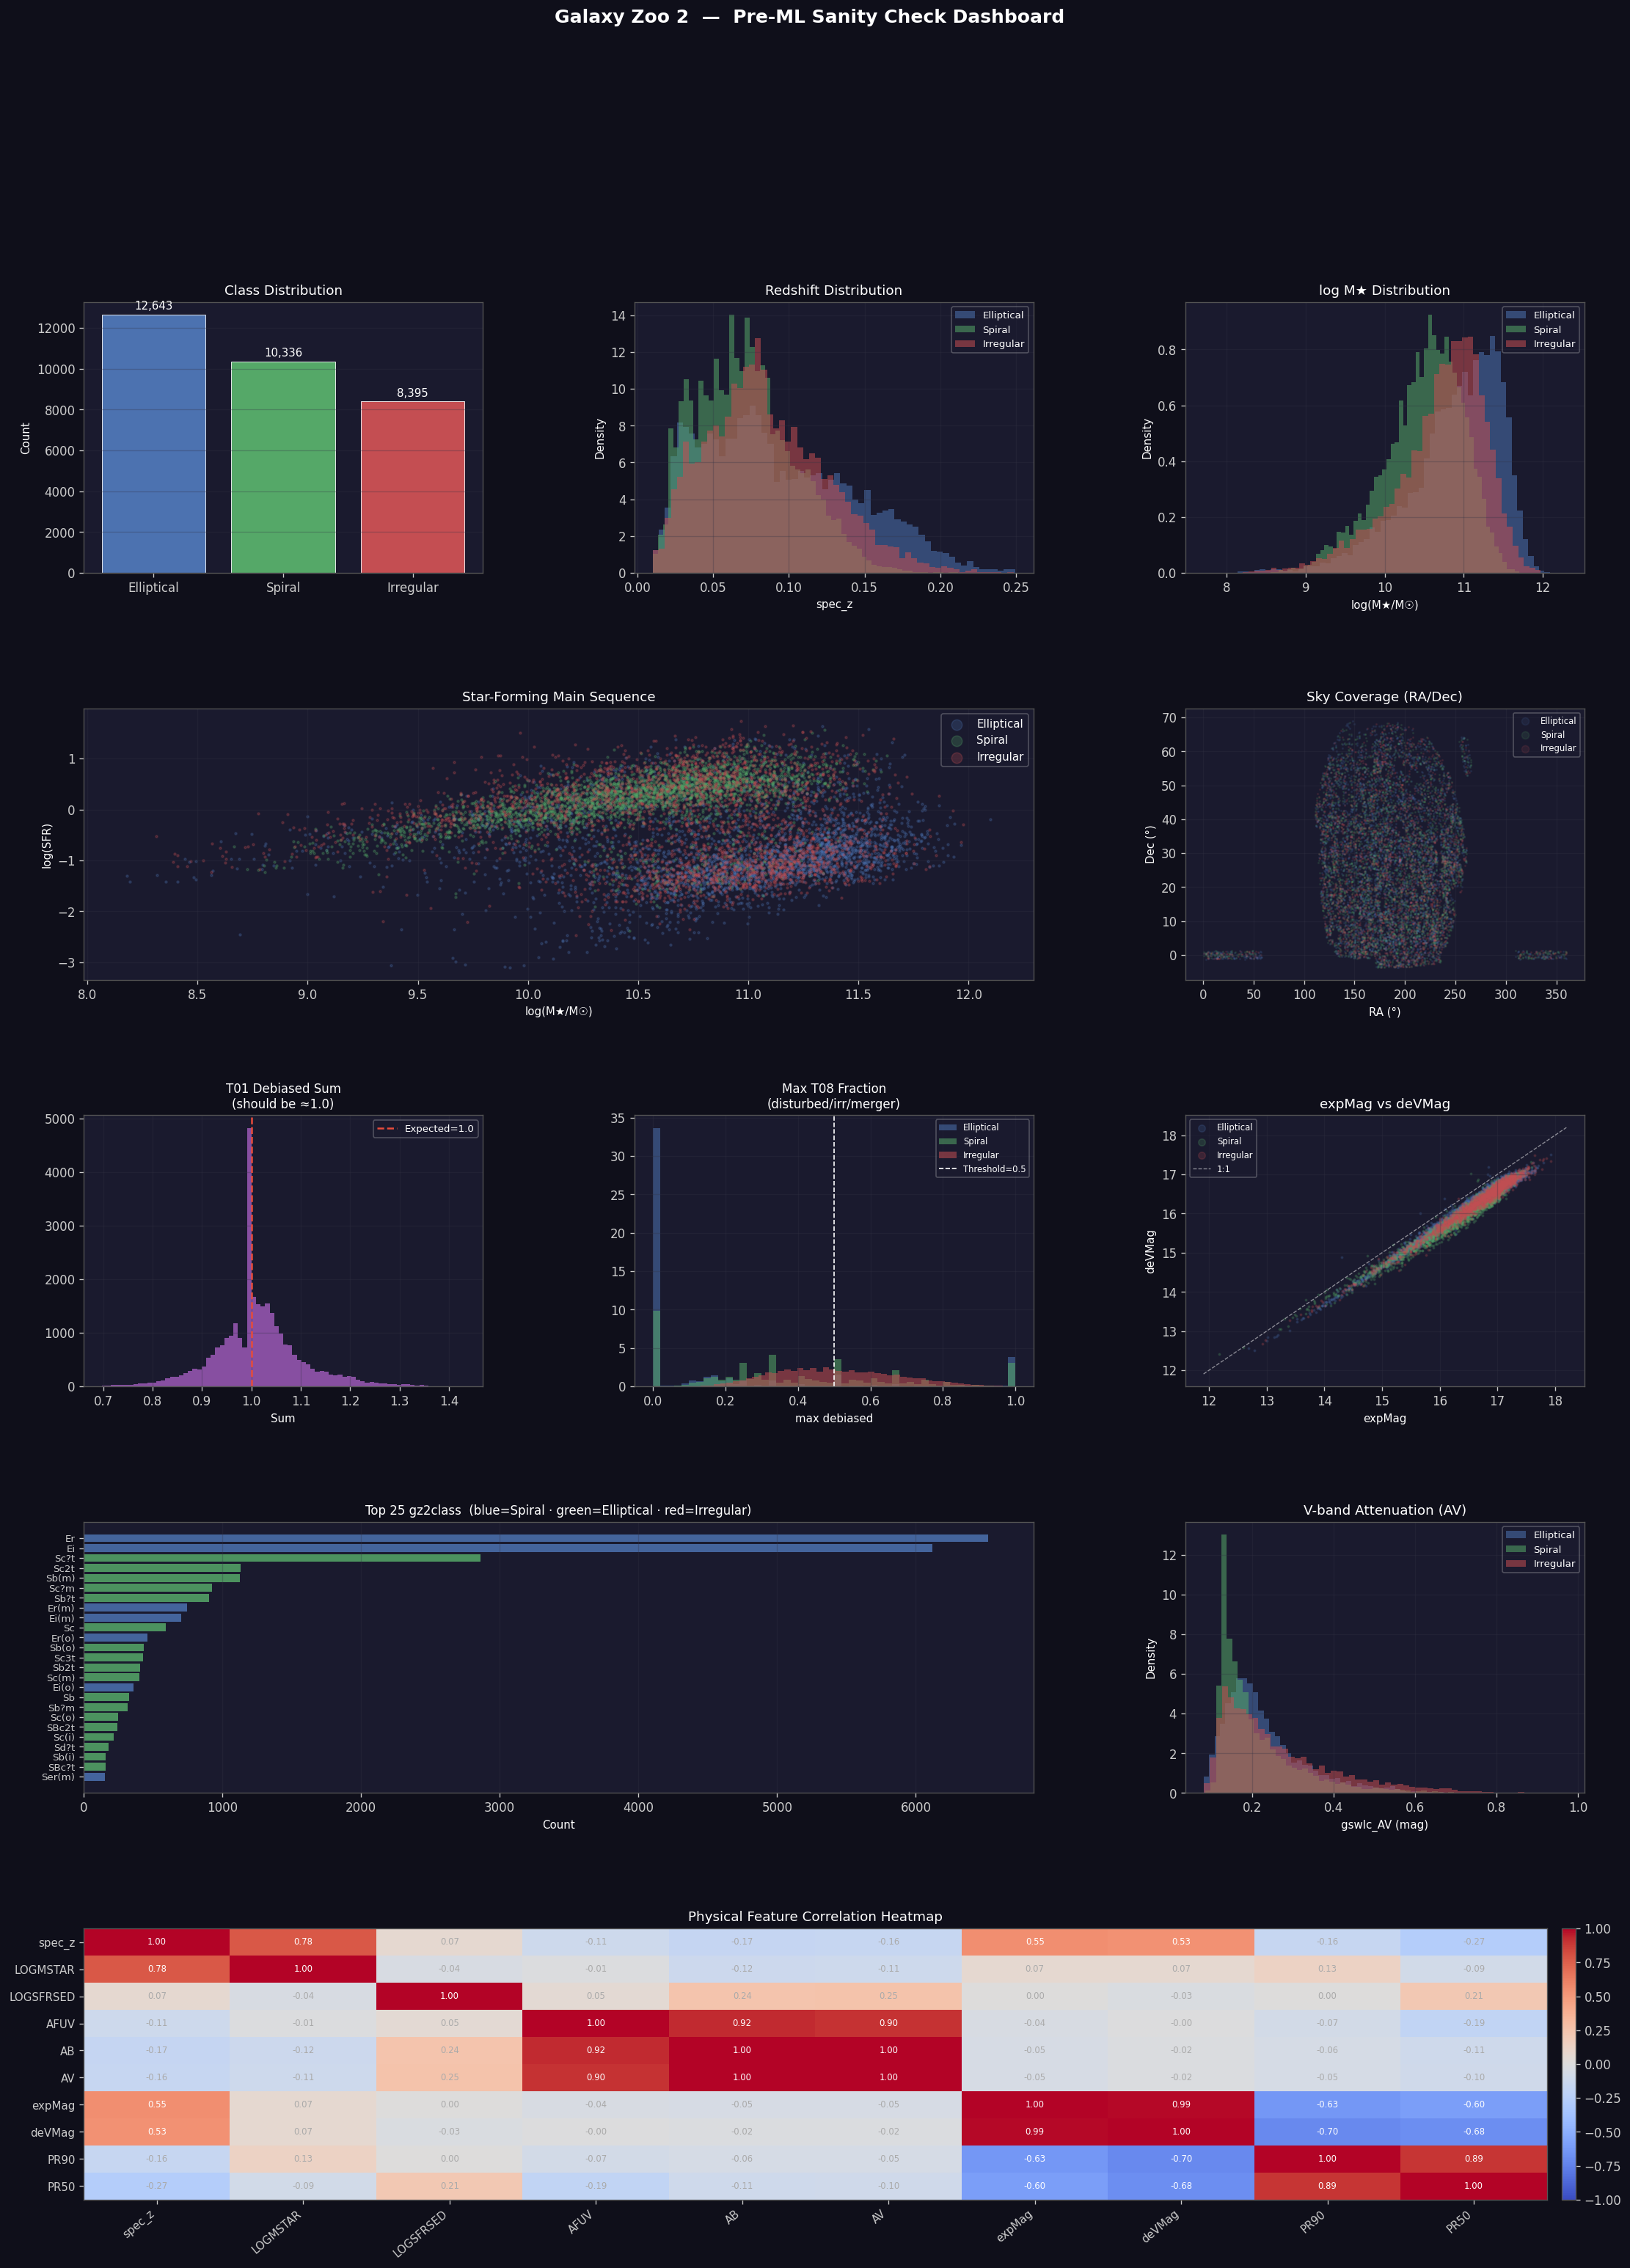

Dashboard saved → sanity_plots.png


In [18]:
dark_bg  = "#0f0f1a"
panel_bg = "#1a1a2e"

with plt.rc_context({
    "text.color": "white", "axes.labelcolor": "white",
    "xtick.color": "#ccc",  "ytick.color": "#ccc",
    "axes.edgecolor": "#555", "axes.facecolor": panel_bg,
    "figure.facecolor": dark_bg, "grid.color": "#333344",
}):
    fig = plt.figure(figsize=(22, 28), facecolor=dark_bg)
    gs  = gridspec.GridSpec(5, 3, figure=fig, hspace=0.50, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    counts = df["morphology_label"].value_counts().sort_index()
    bars = ax.bar([LABEL_MAP[i] for i in range(3)], counts.values,
                  color=[COLORS[i] for i in range(3)], edgecolor="white", linewidth=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                f"{val:,}", ha="center", va="bottom", fontsize=9, color="white")
    ax.set_title("Class Distribution", color="white", fontsize=11)
    ax.set_ylabel("Count", fontsize=9); ax.grid(axis="y", alpha=0.3)

    ax = fig.add_subplot(gs[0, 1])
    if "spec_z" in df.columns:
        for lbl in [0,1,2]:
            sub = df[df["morphology_label"]==lbl]["spec_z"].dropna()
            ax.hist(sub, bins=60, alpha=0.55, color=COLORS[lbl], label=LABEL_MAP[lbl],
                    density=True, histtype="stepfilled")
        ax.set_title("Redshift Distribution", color="white", fontsize=11)
        ax.set_xlabel("spec_z", fontsize=9); ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[0, 2])
    if "gswlc_LOGMSTAR" in df.columns:
        for lbl in [0,1,2]:
            sub = df[df["morphology_label"]==lbl]["gswlc_LOGMSTAR"].dropna()
            ax.hist(sub, bins=60, alpha=0.55, color=COLORS[lbl], label=LABEL_MAP[lbl],
                    density=True, histtype="stepfilled")
        ax.set_title("log M★ Distribution", color="white", fontsize=11)
        ax.set_xlabel("log(M★/M☉)", fontsize=9); ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, :2])
    if "gswlc_LOGMSTAR" in df.columns and "gswlc_LOGSFRSED" in df.columns:
        for lbl in [0,1,2]:
            sub = df[df["morphology_label"]==lbl][["gswlc_LOGMSTAR","gswlc_LOGSFRSED"]].dropna()
            sub = sub.sample(min(3000, len(sub)), random_state=42)
            ax.scatter(sub["gswlc_LOGMSTAR"], sub["gswlc_LOGSFRSED"],
                       alpha=0.25, s=3, color=COLORS[lbl], label=LABEL_MAP[lbl])
        ax.set_title("Star-Forming Main Sequence", color="white", fontsize=11)
        ax.set_xlabel("log(M★/M☉)", fontsize=9); ax.set_ylabel("log(SFR)", fontsize=9)
        ax.legend(fontsize=9, framealpha=0.3, markerscale=5); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[1, 2])
    if "ra" in df.columns and "dec" in df.columns:
        samp = df.sample(min(12000, len(df)), random_state=42)
        for lbl in [0,1,2]:
            sub = samp[samp["morphology_label"]==lbl]
            ax.scatter(sub["ra"], sub["dec"], alpha=0.12, s=1,
                       color=COLORS[lbl], label=LABEL_MAP[lbl])
        ax.set_title("Sky Coverage (RA/Dec)", color="white", fontsize=11)
        ax.set_xlabel("RA (°)", fontsize=9); ax.set_ylabel("Dec (°)", fontsize=9)
        ax.legend(fontsize=7, framealpha=0.3, markerscale=6); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 0])
    avail_t01 = [c for c in T01_DEBIAS_COLS if c in df.columns]
    if len(avail_t01) == 3:
        t01_sum = df[avail_t01].sum(axis=1)
        ax.hist(t01_sum, bins=80, color="#9b59b6", edgecolor="none", alpha=0.85)
        ax.axvline(1.0, color="#e74c3c", ls="--", lw=1.5, label="Expected=1.0")
        ax.set_title("T01 Debiased Sum\n(should be ≈1.0)", color="white", fontsize=10)
        ax.set_xlabel("Sum", fontsize=9); ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 1])
    avail_t08 = [c for c in T08_IRREG_COLS if c in df.columns]
    if avail_t08:
        for lbl in [0,1,2]:
            sub = df[df["morphology_label"]==lbl][avail_t08].max(axis=1).dropna()
            ax.hist(sub, bins=50, alpha=0.55, color=COLORS[lbl], label=LABEL_MAP[lbl],
                    density=True, histtype="stepfilled")
        ax.axvline(0.5, color="white", ls="--", lw=1, label="Threshold=0.5")
        ax.set_title("Max T08 Fraction\n(disturbed/irr/merger)", color="white", fontsize=10)
        ax.set_xlabel("max debiased", fontsize=9); ax.legend(fontsize=7, framealpha=0.3); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[2, 2])
    if "expMag" in df.columns and "deVMag" in df.columns:
        samp = df.sample(min(8000, len(df)), random_state=1)
        for lbl in [0,1,2]:
            sub = samp[samp["morphology_label"]==lbl]
            ax.scatter(sub["expMag"], sub["deVMag"], alpha=0.2, s=2,
                       color=COLORS[lbl], label=LABEL_MAP[lbl])
        lo = df[["expMag","deVMag"]].min().min(); hi = df[["expMag","deVMag"]].max().max()
        ax.plot([lo,hi],[lo,hi],"w--",lw=0.8,alpha=0.5,label="1:1")
        ax.set_title("expMag vs deVMag", color="white", fontsize=11)
        ax.set_xlabel("expMag", fontsize=9); ax.set_ylabel("deVMag", fontsize=9)
        ax.legend(fontsize=7, framealpha=0.3, markerscale=4); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[3, :2])
    top25 = df["gz2class"].value_counts().head(25)
    bar_colors = []
    for cls in top25.index:
        if str(cls).startswith(SPIRAL_PREFIXES):       bar_colors.append(COLORS[1])
        elif str(cls).startswith(ELLIPTICAL_PREFIXES): bar_colors.append(COLORS[0])
        else:                                          bar_colors.append(COLORS[2])
    ax.barh(range(len(top25)), top25.values, color=bar_colors, alpha=0.85, edgecolor="none")
    ax.set_yticks(range(len(top25))); ax.set_yticklabels(top25.index, fontsize=8)
    ax.invert_yaxis(); ax.set_xlabel("Count", fontsize=9)
    ax.set_title("Top 25 gz2class  (blue=Spiral · green=Elliptical · red=Irregular)",
                 color="white", fontsize=10)
    ax.grid(axis="x", alpha=0.3)

    ax = fig.add_subplot(gs[3, 2])
    if "gswlc_AV" in df.columns:
        for lbl in [0,1,2]:
            sub = df[df["morphology_label"]==lbl]["gswlc_AV"].dropna()
            ax.hist(sub, bins=60, alpha=0.55, color=COLORS[lbl], label=LABEL_MAP[lbl],
                    density=True, histtype="stepfilled")
        ax.set_title("V-band Attenuation (AV)", color="white", fontsize=11)
        ax.set_xlabel("gswlc_AV (mag)", fontsize=9); ax.set_ylabel("Density", fontsize=9)
        ax.legend(fontsize=8, framealpha=0.3); ax.grid(alpha=0.3)

    ax = fig.add_subplot(gs[4, :])
    phys = ["spec_z","gswlc_LOGMSTAR","gswlc_LOGSFRSED","gswlc_AFUV",
            "gswlc_AB","gswlc_AV","expMag","deVMag","PR90","PR50"]
    avail_phys = [c for c in phys if c in df.columns]
    if len(avail_phys) >= 3:
        corr = df[avail_phys].corr()
        short = [c.replace("gswlc_","") for c in avail_phys]
        im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(avail_phys))); ax.set_yticks(range(len(avail_phys)))
        ax.set_xticklabels(short, rotation=40, ha="right", fontsize=9)
        ax.set_yticklabels(short, fontsize=9)
        for i in range(len(avail_phys)):
            for j in range(len(avail_phys)):
                val = corr.values[i,j]
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(val)>0.5 else "#aaa")
        plt.colorbar(im, ax=ax, fraction=0.015, pad=0.01)
        ax.set_title("Physical Feature Correlation Heatmap", color="white", fontsize=11)

    fig.suptitle("Galaxy Zoo 2  —  Pre-ML Sanity Check Dashboard",
                 fontsize=15, color="white", y=0.999, fontweight="bold")
    plt.savefig("sanity_plots.png", dpi=150, bbox_inches="tight", facecolor=dark_bg)
    plt.show()
    print("Dashboard saved → sanity_plots.png")